# Paid Benchmark Run Analysis

This notebook analyzes paid benchmark run data for a specific run hash. Enter the hash ID in the Configuration section below to analyze your run results.

## Overview

The paid benchmark runner processes prompts through multiple OpenRouter models with budget tracking and resumable state. This notebook provides comprehensive analysis of:

- **Coverage**: Which models answered which prompts
- **Completion**: Statistics on fully vs. partially completed prompts
- **Costs**: Total spending, cost per model, and efficiency metrics
- **Performance**: Latency, token usage, and throughput
- **Quality**: Response length, errors, and retry statistics
- **Timeline**: Processing rate and time-based patterns

## Usage

1. Set the `RUN_HASH` variable in the Configuration section (default: `"95b19ea16ead8ca5"`)
2. Run all cells sequentially (Cell → Run All)
3. Review the analysis sections and visualizations
4. Export summaries are saved to `run_{HASH}/analysis/` directory

## Data Sources

- **results.csv**: All model responses with metadata (tokens, cost, latency, errors)
- **state.json**: Run state including total costs and model-level cost breakdowns

## Expected Models

The notebook expects 14 models by default (Amazon Nova Premier is excluded due to outages):
- Anthropic: Claude Opus 4.5, Sonnet 4.5, Sonnet 4
- Google: Gemini 3 Pro Preview, Gemini 2.5 Pro, Gemini 2.5 Flash
- OpenAI: GPT-5.1, GPT-OSS-120B
- AllenAI: Olmo 3 32B Think
- xAI: Grok 4.1 Fast (free)
- Chinese: Moonshot Kimi K2 Thinking, DeepSeek R1, Qwen 3 Max
- European: Mistral Medium 3.1

In [1269]:
# Standard library imports
from __future__ import annotations
from pathlib import Path
from datetime import datetime
import json
import sys
import warnings

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode

# Project imports
# Add project root to path
project_root = Path().resolve()
if project_root.name == 'paid_runs':
    project_root = project_root.parent.parent
elif project_root.name == 'outputs':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

# Configure warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Initialize plotly for Jupyter (if available)
try:
    init_notebook_mode(connected=True)
except Exception:
    pass


## Configuration

Enter the run hash ID below to analyze a specific benchmark run.


In [1270]:
# Hash ID Input
RUN_HASH = "95b19ea16ead8ca5"  # Change this to analyze a different run

# Define paths - try relative to current directory first, then project root
# If notebook is in outputs/paid_runs/, run_dir should be in same directory
run_dir = Path(f"run_{RUN_HASH}")
if not run_dir.exists():
    # Try from project root
    run_dir = Path(f"outputs/paid_runs/run_{RUN_HASH}").resolve()
    if not run_dir.exists():
        # Try absolute path from project root (where project_root was determined)
        run_dir = project_root / "outputs" / "paid_runs" / f"run_{RUN_HASH}"

csv_path = run_dir / "results.csv"
state_path = run_dir / "state.json"

# Validate paths exist
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")
if not csv_path.exists():
    raise FileNotFoundError(f"Results CSV file not found: {csv_path}")
if not state_path.exists():
    raise FileNotFoundError(f"State JSON file not found: {state_path}")

# Print relative paths for cleaner output
run_dir_rel = run_dir.relative_to(project_root) if run_dir.is_relative_to(project_root) else run_dir
csv_path_rel = csv_path.relative_to(project_root) if csv_path.is_relative_to(project_root) else csv_path
state_path_rel = state_path.relative_to(project_root) if state_path.is_relative_to(project_root) else state_path
print(f"Run directory: {run_dir_rel}")
print(f"Results CSV: {csv_path_rel}")
print(f"State JSON: {state_path_rel}")


Run directory: run_95b19ea16ead8ca5
Results CSV: run_95b19ea16ead8ca5/results.csv
State JSON: run_95b19ea16ead8ca5/state.json


## Data Loading


In [1271]:
def load_paid_run_data(csv_path: Path) -> pd.DataFrame:
    """Load and validate CSV data from paid benchmark run.
    
    Args:
        csv_path: Path to results.csv file
        
    Returns:
        DataFrame with run data
    """
    df = pd.read_csv(csv_path, encoding='utf-8')
    
    # Expected columns
    expected_cols = [
        'prompt_identifier', 'prompt_body', 'model_id', 'response_text',
        'input_tokens', 'output_tokens', 'total_tokens', 'cost_usd',
        'latency_ms', 'timestamp', 'error', 'retry_count'
    ]
    
    missing_cols = set(expected_cols) - set(df.columns)
    if missing_cols:
        raise ValueError(f"CSV missing expected columns: {missing_cols}")
    
    return df

def analyze_costs(state_path: Path) -> dict:
    """Extract cost information from state.json.
    
    Args:
        state_path: Path to state.json file
        
    Returns:
        Dictionary with cost information
    """
    with state_path.open('r', encoding='utf-8') as f:
        state = json.load(f)
    
    return {
        'total_cost': state.get('total_cost', 0.0),
        'model_costs': state.get('model_costs', {}),
        'started_at': state.get('started_at'),
        'last_updated': state.get('last_updated'),
    }

def validate_data(df: pd.DataFrame) -> dict:
    """Run data quality checks.
    
    Args:
        df: DataFrame to validate
        
    Returns:
        Dictionary with validation results
    """
    results = {}
    
    # Convert to string for safe string operations (handles NaN)
    response_text_str = df['response_text'].astype(str)
    error_str = df['error'].astype(str)
    
    # Check for empty response_text (NaN becomes 'nan' string, so check for that too)
    empty_responses = (
        df['response_text'].isna() | 
        (response_text_str == 'nan') |
        (response_text_str.str.strip() == '')
    )
    results['empty_responses'] = empty_responses.sum()
    results['empty_response_ids'] = df[empty_responses][['prompt_identifier', 'model_id']].to_dict('records') if empty_responses.any() else []
    
    # Check for errors (NaN becomes 'nan' string, so exclude that)
    has_errors = (
        df['error'].notna() & 
        (error_str != 'nan') & 
        (error_str.str.strip() != '')
    )
    results['error_count'] = has_errors.sum()
    
    # Count records
    results['total_records'] = len(df)
    results['unique_prompts'] = df['prompt_identifier'].nunique()
    results['unique_models'] = df['model_id'].nunique()
    
    return results

# Load data
df = load_paid_run_data(csv_path)
cost_data = analyze_costs(state_path)
validation = validate_data(df)

print(f"✓ Loaded {len(df)} records from CSV")
print(f"✓ Loaded cost data: ${cost_data['total_cost']:.4f} total")
print(f"\nData shape: {df.shape}")
print(f"Data columns: {list(df.columns)}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nValidation results:")
print(f"  Total records: {validation['total_records']}")
print(f"  Unique prompts: {validation['unique_prompts']}")
print(f"  Unique models: {validation['unique_models']}")
print(f"  Empty responses: {validation['empty_responses']}")
print(f"  Errors: {validation['error_count']}")


✓ Loaded 7500 records from CSV
✓ Loaded cost data: $49.0645 total

Data shape: (7500, 12)
Data columns: ['prompt_identifier', 'prompt_body', 'model_id', 'response_text', 'input_tokens', 'output_tokens', 'total_tokens', 'cost_usd', 'latency_ms', 'timestamp', 'error', 'retry_count']

Memory usage: 58.13 MB

Validation results:
  Total records: 7500
  Unique prompts: 500
  Unique models: 15
  Empty responses: 0
  Errors: 0


## Completion Analysis


In [1272]:
def calculate_completion_matrix(df: pd.DataFrame, models: list) -> pd.DataFrame:
    """Create prompt×model completion matrix.
    
    Args:
        df: DataFrame with run data
        models: List of expected model IDs
        
    Returns:
        DataFrame with completion matrix (1 = completed, 0 = missing)
    """
    # Convert to string for safe string operations (handles NaN)
    error_str = df['error'].astype(str)
    response_text_str = df['response_text'].astype(str)
    
    # Filter successful responses (no error and has response text)
    df_success = df[
        (df['error'].isna() | (error_str == 'nan') | (error_str.str.strip() == '')) &
        (df['response_text'].notna()) &
        (response_text_str != 'nan') &
        (response_text_str.str.strip() != '')
    ].copy()
    
    # Create pivot table
    completion = df_success.groupby(['prompt_identifier', 'model_id']).size().unstack(fill_value=0)
    
    # Ensure all expected models are in columns
    for model in models:
        if model not in completion.columns:
            completion[model] = 0
    
    # Convert to binary (1 = has response, 0 = missing)
    completion = (completion > 0).astype(int)
    
    return completion

# Expected models (from config.py)
EXPECTED_MODELS = [
    "anthropic/claude-opus-4.5",
    "anthropic/claude-sonnet-4.5",
    "anthropic/claude-sonnet-4",
    "google/gemini-3-pro-preview",
    "google/gemini-2.5-pro",
    "google/gemini-2.5-flash",
    "openai/gpt-5.1",
    "openai/gpt-oss-120b",
    "allenai/olmo-3-32b-think",
    "x-ai/grok-4.1-fast:free",
    "moonshotai/kimi-k2-thinking",
    "deepseek/deepseek-r1",
    "qwen/qwen3-max",
    "mistralai/mistral-medium-3.1",
    "google/gemma-3n-e4b-it"
    # "amazon/nova-premier-v1"
]

# Calculate completion matrix
completion_matrix = calculate_completion_matrix(df, EXPECTED_MODELS)

# Calculate completion rates
completion_by_model = completion_matrix.sum(axis=0).sort_values(ascending=False)
completion_by_prompt = completion_matrix.sum(axis=1).sort_values(ascending=False)

# Summary statistics
total_prompts = len(completion_matrix)
total_models = len(EXPECTED_MODELS)
fully_completed_prompts = (completion_by_prompt == total_models).sum()
incomplete_prompts = total_prompts - fully_completed_prompts
overall_completion = (completion_matrix.sum().sum() / (total_prompts * total_models) * 100)

print("Completion Summary:")
print(f"  Total prompts: {total_prompts}")
print(f"  Expected models: {total_models}")
print(f"  Fully completed prompts: {fully_completed_prompts}")
print(f"  Incomplete prompts: {incomplete_prompts}")
print(f"  Overall completion rate: {overall_completion:.1f}%")
print(f"\nCompletion by Model:")
for model, count in completion_by_model.items():
    rate = (count / total_prompts) * 100
    print(f"  {model}: {count}/{total_prompts} ({rate:.1f}%)")


Completion Summary:
  Total prompts: 500
  Expected models: 15
  Fully completed prompts: 500
  Incomplete prompts: 0
  Overall completion rate: 100.0%

Completion by Model:
  allenai/olmo-3-32b-think: 500/500 (100.0%)
  anthropic/claude-opus-4.5: 500/500 (100.0%)
  anthropic/claude-sonnet-4: 500/500 (100.0%)
  anthropic/claude-sonnet-4.5: 500/500 (100.0%)
  deepseek/deepseek-r1: 500/500 (100.0%)
  google/gemini-2.5-flash: 500/500 (100.0%)
  google/gemini-2.5-pro: 500/500 (100.0%)
  google/gemini-3-pro-preview: 500/500 (100.0%)
  google/gemma-3n-e4b-it: 500/500 (100.0%)
  mistralai/mistral-medium-3.1: 500/500 (100.0%)
  moonshotai/kimi-k2-thinking: 500/500 (100.0%)
  openai/gpt-5.1: 500/500 (100.0%)
  openai/gpt-oss-120b: 500/500 (100.0%)
  qwen/qwen3-max: 500/500 (100.0%)
  x-ai/grok-4.1-fast:free: 500/500 (100.0%)


In [1273]:
# Identify missing combinations
# Convert to string for safe string operations (handles NaN)
error_str = df['error'].astype(str)
response_text_str = df['response_text'].astype(str)

df_success = df[
    (df['error'].isna() | (error_str == 'nan') | (error_str.str.strip() == '')) &
    (df['response_text'].notna()) &
    (response_text_str != 'nan') &
    (response_text_str.str.strip() != '')
].copy()

all_prompts = set(completion_matrix.index)
all_models = set(EXPECTED_MODELS)
actual_combinations = set(zip(df_success['prompt_identifier'], df_success['model_id']))
expected_combinations = {(p, m) for p in all_prompts for m in all_models}
missing_combinations = expected_combinations - actual_combinations

if missing_combinations:
    missing_df = pd.DataFrame(list(missing_combinations), columns=['prompt_identifier', 'model_id'])
    print(f"Missing combinations: {len(missing_df)}")
    print("\nFirst 20 missing combinations:")
    print(missing_df.head(20).to_string(index=False))
    if len(missing_df) > 20:
        print(f"\n... and {len(missing_df) - 20} more")
else:
    print("✓ No missing combinations - all prompts answered by all models!")


✓ No missing combinations - all prompts answered by all models!


## Model Coverage


In [1274]:
# Model-level statistics
# Convert to string for safe string operations (handles NaN)
error_str = df['error'].astype(str)
response_text_str = df['response_text'].astype(str)

df_success = df[
    (df['error'].isna() | (error_str == 'nan') | (error_str.str.strip() == '')) &
    (df['response_text'].notna()) &
    (response_text_str != 'nan') &
    (response_text_str.str.strip() != '')
].copy()

# Calculate response length
df_success['response_length'] = df_success['response_text'].str.len()
df_success['word_count'] = df_success['response_text'].str.split().str.len()

# Model statistics
model_stats = df_success.groupby('model_id').agg({
    'prompt_identifier': 'count',
    'response_length': ['mean', 'median', 'std'],
    'word_count': 'mean',
}).round(2)
# Count errors separately (errors are already filtered out, so this should be 0)
model_stats['errors'] = 0  # All rows in df_success are successful by definition

model_stats.columns = ['responses', 'avg_length', 'median_length', 'std_length', 'avg_words', 'errors']
model_stats['success_rate'] = ((model_stats['responses'] - model_stats['errors']) / model_stats['responses'] * 100).round(1)

print("Model Statistics:")
print(model_stats.sort_values('responses', ascending=False).to_string())


Model Statistics:
                              responses  avg_length  median_length  std_length  avg_words  errors  success_rate
model_id                                                                                                       
allenai/olmo-3-32b-think            500     4589.16         4567.0      901.81     713.60       0         100.0
anthropic/claude-opus-4.5           500     1468.10         1386.0      567.72     238.11       0         100.0
anthropic/claude-sonnet-4           500     1393.42         1410.5      164.09     224.36       0         100.0
anthropic/claude-sonnet-4.5         500     1528.27         1521.0      198.90     253.17       0         100.0
deepseek/deepseek-r1                500     2613.61         1967.0     1433.43     391.96       0         100.0
google/gemini-2.5-flash             500     2899.28         2697.0     1498.46     470.95       0         100.0
google/gemini-2.5-pro               500     3531.12         3472.5      924.20     604

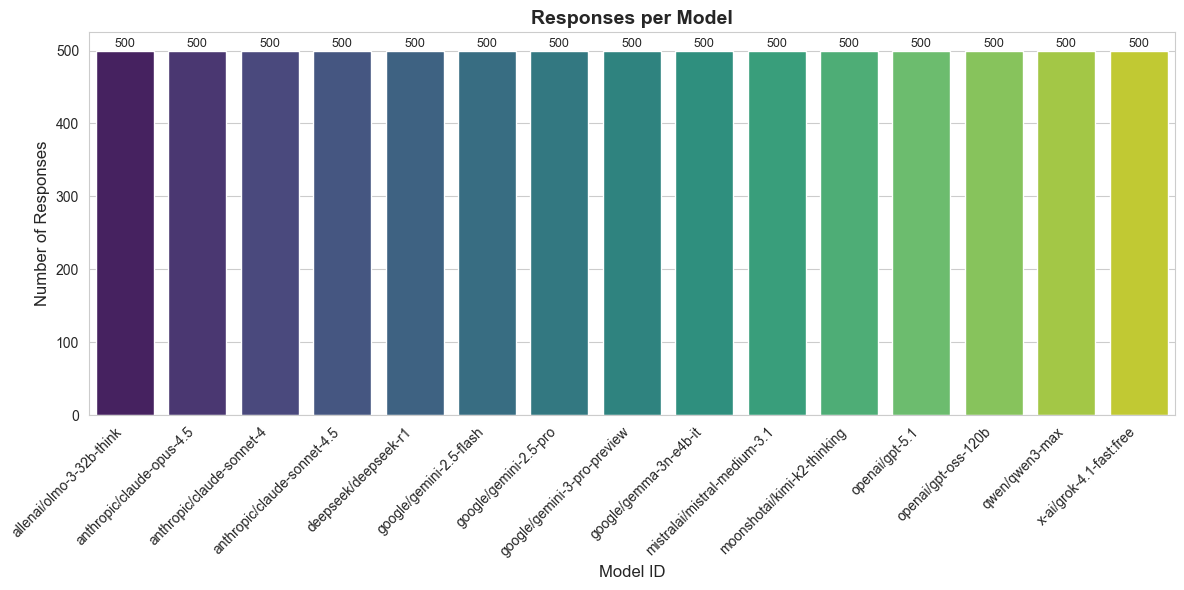

In [1275]:
# Bar chart of responses per model
plt.figure(figsize=(max(12, len(model_stats) * 0.6), 6))
ax = sns.barplot(
    data=model_stats.reset_index(),
    x='model_id',
    y='responses',
    palette='viridis'
)
plt.title("Responses per Model", fontsize=14, fontweight='bold')
plt.xlabel("Model ID", fontsize=12)
plt.ylabel("Number of Responses", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for i, (idx, row) in enumerate(model_stats.iterrows()):
    ax.text(i, row['responses'] + 1, f"{int(row['responses'])}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [1276]:
# Heatmap of completion matrix - only show prompts with at least one missing model
completion_sorted = completion_matrix.sort_index(axis=0).sort_index(axis=1)

# Filter to only show rows (prompts) with at least one uncompleted item
# A row sum less than total_models means at least one model is missing
incomplete_prompts_mask = completion_sorted.sum(axis=1) < total_models
completion_filtered = completion_sorted[incomplete_prompts_mask]

if len(completion_filtered) > 0:
    plt.figure(figsize=(max(12, len(completion_filtered.columns) * 0.5), max(6, len(completion_filtered.index) * 0.4)))
    sns.heatmap(
        completion_filtered,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        cbar_kws={'label': 'Completed (1=Yes, 0=No)'},
        linewidths=0.5,
        linecolor='gray'
    )
    plt.title("Completion Matrix: Incomplete Prompts × Models", fontsize=14, fontweight='bold')
    plt.xlabel("Model ID", fontsize=12)
    plt.ylabel("Prompt Identifier", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print(f"Showing {len(completion_filtered)} incomplete prompts (out of {len(completion_sorted)} total)")
    print(f"Completion matrix: {completion_filtered.shape[0]} prompts × {completion_filtered.shape[1]} models")
    print(f"Total combinations shown: {completion_filtered.sum().sum()}")
    print(f"Missing combinations shown: {(completion_filtered == 0).sum().sum()}")
else:
    print("✓ All prompts are fully completed! No incomplete prompts to display.")
    print(f"Total prompts: {len(completion_sorted)}")
    print(f"All prompts completed by all {total_models} models")


✓ All prompts are fully completed! No incomplete prompts to display.
Total prompts: 500
All prompts completed by all 15 models


## Cost Analysis


In [1277]:
# Cost breakdown
total_cost = cost_data['total_cost']
model_costs = cost_data['model_costs']

# Cost per prompt (aggregate)
cost_per_prompt = df_success.groupby('prompt_identifier')['cost_usd'].sum().sort_values(ascending=False)
avg_cost_per_response = df_success['cost_usd'].mean()

print("Cost Summary:")
print(f"  Total cost: ${total_cost:.4f}")
print(f"  Average cost per response: ${avg_cost_per_response:.4f}")
print(f"\nCost per Model (from state.json):")
for model, cost in sorted(model_costs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model}: ${cost:.4f}")

# Create cost DataFrame
cost_df = pd.DataFrame(list(model_costs.items()), columns=['model_id', 'total_cost'])
cost_df = cost_df.sort_values('total_cost', ascending=False)


Cost Summary:
  Total cost: $49.0645
  Average cost per response: $0.0070

Cost per Model (from state.json):
  google/gemini-2.5-pro: $12.6683
  google/gemini-3-pro-preview: $11.2781
  openai/gpt-5.1: $5.5222
  anthropic/claude-opus-4.5: $5.3727
  anthropic/claude-sonnet-4.5: $3.3686
  anthropic/claude-sonnet-4: $2.9515
  qwen/qwen3-max: $2.0582
  moonshotai/kimi-k2-thinking: $1.8668
  deepseek/deepseek-r1: $1.4433
  google/gemini-2.5-flash: $0.8627
  allenai/olmo-3-32b-think: $0.6379
  mistralai/mistral-medium-3.1: $0.6319
  openai/gpt-oss-120b: $0.3847
  google/gemma-3n-e4b-it: $0.0176
  x-ai/grok-4.1-fast:free: $0.0000
  amazon/nova-premier-v1: $0.0000


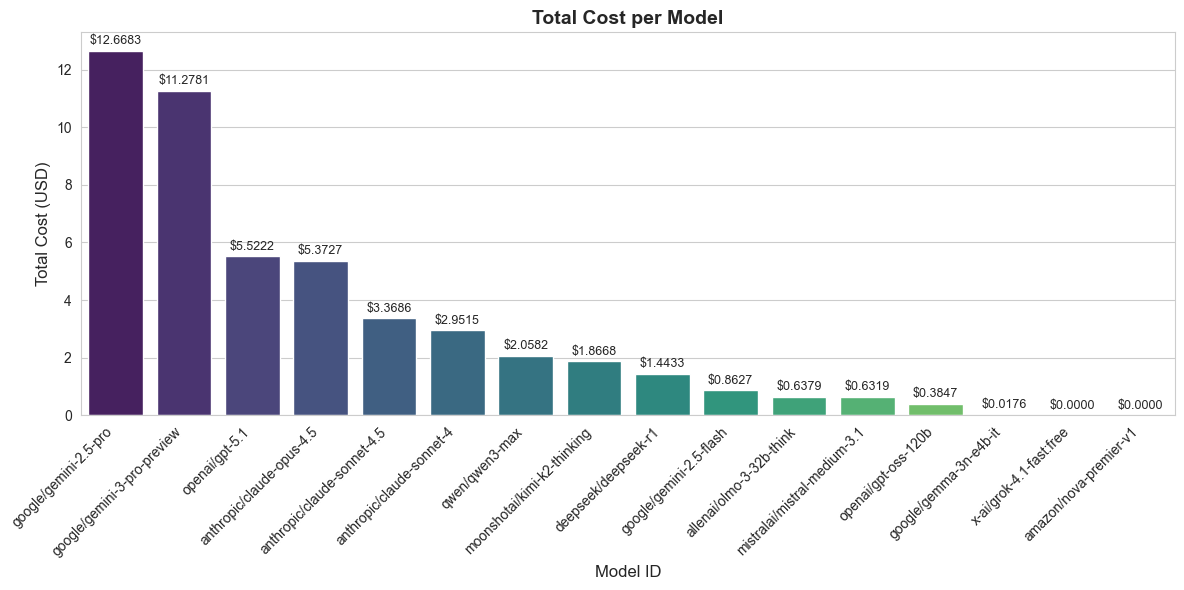

In [1278]:
# Bar chart of cost per model
plt.figure(figsize=(max(12, len(cost_df) * 0.6), 6))
ax = sns.barplot(
    data=cost_df,
    x='model_id',
    y='total_cost',
    palette='viridis'
)
plt.title("Total Cost per Model", fontsize=14, fontweight='bold')
plt.xlabel("Model ID", fontsize=12)
plt.ylabel("Total Cost (USD)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add cost labels on bars
for i, (idx, row) in enumerate(cost_df.iterrows()):
    ax.text(i, row['total_cost'] + max(cost_df['total_cost']) * 0.01, f"${row['total_cost']:.4f}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


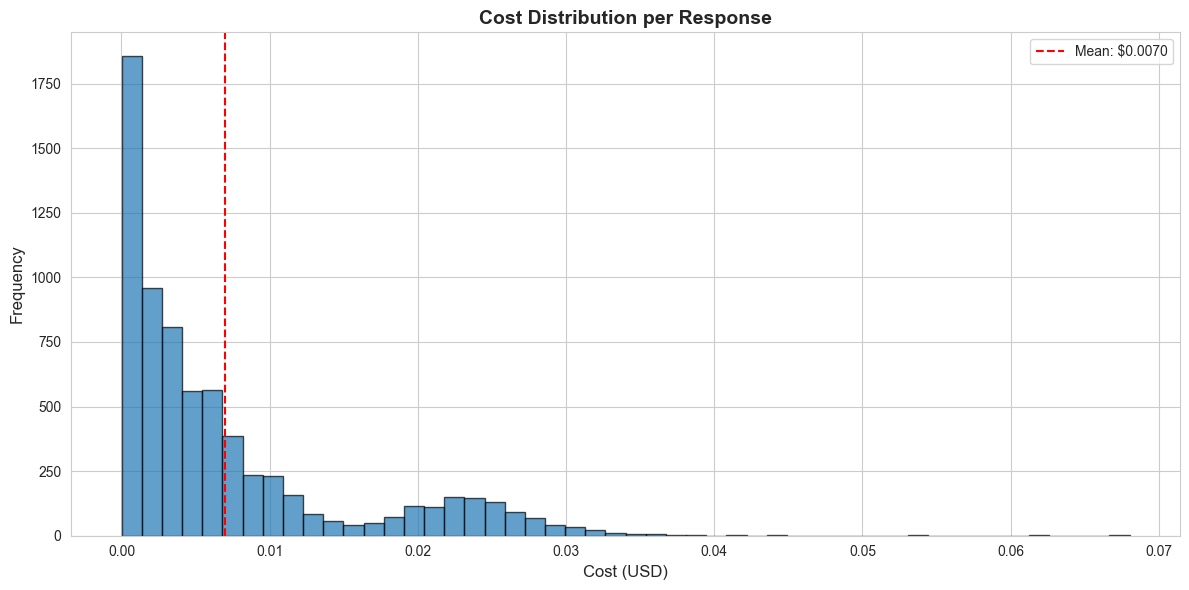

In [1279]:
# Cost distribution histogram
df_with_cost = df_success[df_success['cost_usd'] > 0].copy()

if len(df_with_cost) > 0:
    plt.figure(figsize=(12, 6))
    plt.hist(df_with_cost['cost_usd'], bins=50, edgecolor='black', alpha=0.7)
    plt.title("Cost Distribution per Response", fontsize=14, fontweight='bold')
    plt.xlabel("Cost (USD)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.axvline(df_with_cost['cost_usd'].mean(), color='red', linestyle='--', 
                label=f"Mean: ${df_with_cost['cost_usd'].mean():.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No cost data available for distribution plot.")


In [1280]:
# Cost efficiency metrics
df_with_cost = df_success[df_success['cost_usd'] > 0].copy()

if len(df_with_cost) > 0:
    # Cost per token
    df_with_cost['cost_per_token'] = df_with_cost['cost_usd'] / df_with_cost['total_tokens'].replace(0, np.nan)
    
    # Cost per character
    df_with_cost['cost_per_char'] = df_with_cost['cost_usd'] / df_with_cost['response_length'].replace(0, np.nan)
    
    efficiency_stats = df_with_cost.groupby('model_id').agg({
        'cost_per_token': 'mean',
        'cost_per_char': 'mean',
        'total_tokens': 'mean',
        'response_length': 'mean',
    }).round(6)
    
    efficiency_stats.columns = ['cost_per_1k_tokens', 'cost_per_1k_chars', 'avg_tokens', 'avg_chars']
    efficiency_stats['cost_per_1k_tokens'] = efficiency_stats['cost_per_1k_tokens'] * 1000
    efficiency_stats['cost_per_1k_chars'] = efficiency_stats['cost_per_1k_chars'] * 1000
    
    print("Cost Efficiency Metrics (per 1K tokens/chars):")
    print(efficiency_stats.sort_values('cost_per_1k_tokens').to_string())
else:
    print("No cost data available for efficiency analysis.")


Cost Efficiency Metrics (per 1K tokens/chars):
                              cost_per_1k_tokens  cost_per_1k_chars  avg_tokens  avg_chars
model_id                                                                                  
google/gemma-3n-e4b-it                     0.000              0.000    1102.734   2982.246
openai/gpt-oss-120b                        0.000              0.000    2012.580   5449.942
allenai/olmo-3-32b-think                   0.001              0.000    2529.984   4589.162
mistralai/mistral-medium-3.1               0.001              0.001     972.138   2333.256
deepseek/deepseek-r1                       0.002              0.001    1544.158   2613.606
google/gemini-2.5-flash                    0.002              0.001    1065.250   2899.282
moonshotai/kimi-k2-thinking                0.002              0.002    1796.964   1986.980
qwen/qwen3-max                             0.004              0.002    1024.172   2698.746
anthropic/claude-sonnet-4                  

## Performance Metrics


In [1281]:
# Latency analysis
latency_stats = df_success.groupby('model_id')['latency_ms'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).round(2)

latency_stats.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Count']
print("Latency Statistics by Model:")
print(latency_stats.sort_values('Mean').to_string())

fastest_model = latency_stats['Mean'].idxmin()
slowest_model = latency_stats['Mean'].idxmax()
print(f"\nFastest model (avg): {fastest_model} ({latency_stats.loc[fastest_model, 'Mean']:.0f} ms)")
print(f"Slowest model (avg): {slowest_model} ({latency_stats.loc[slowest_model, 'Mean']:.0f} ms)")


Latency Statistics by Model:
                                  Mean   Median       Std    Min     Max  Count
model_id                                                                       
google/gemini-2.5-flash        4996.57   4623.5   2614.60    838   20714    500
anthropic/claude-sonnet-4     10337.63  10148.5   2119.97   4995   37026    500
anthropic/claude-opus-4.5     11057.31  10461.5   3210.57   5819   35040    500
openai/gpt-oss-120b           11327.84   8318.5   8602.77   2861   87890    500
anthropic/claude-sonnet-4.5   11918.36  11642.0   2133.29   6543   35935    500
mistralai/mistral-medium-3.1  13569.68  11665.0   8259.71   1523   47969    500
x-ai/grok-4.1-fast:free       14363.66  13067.5   6072.35   5196   56552    500
openai/gpt-5.1                19475.25  16994.5  10481.04   4028  117030    500
google/gemma-3n-e4b-it        21282.35  20498.0   8084.11   5047   53065    500
qwen/qwen3-max                21729.33  20995.5   7415.71   8018   48969    500
google/gemi

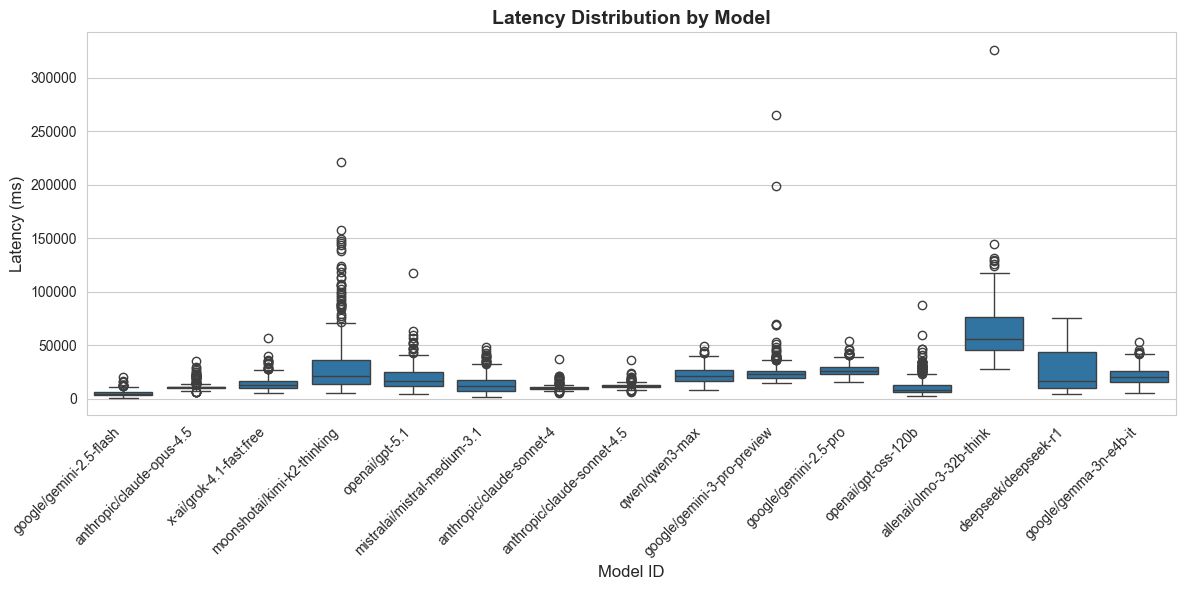

In [1282]:
# Latency box plots by model
plt.figure(figsize=(max(12, df_success['model_id'].nunique() * 0.6), 6))
sns.boxplot(data=df_success, x='model_id', y='latency_ms')
plt.title("Latency Distribution by Model", fontsize=14, fontweight='bold')
plt.xlabel("Model ID", fontsize=12)
plt.ylabel("Latency (ms)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [1283]:
# Token usage analysis
token_stats = df_success.groupby('model_id')[['input_tokens', 'output_tokens', 'total_tokens']].agg([
    'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("Token Usage Statistics by Model:")
print(token_stats.to_string())


Token Usage Statistics by Model:
                             input_tokens                           output_tokens                             total_tokens                            
                                     mean median     std  min   max          mean  median     std   min   max         mean  median     std   min   max
model_id                                                                                                                                              
allenai/olmo-3-32b-think           463.03  426.5  214.48   76  1337       2066.95  1993.5  518.97  1199  8562      2529.98  2449.0  624.58  1382  9363
anthropic/claude-opus-4.5          443.40  405.5  225.73   33  1376        341.13   320.5  132.80     2  1276       784.53   732.5  291.62   220  2061
anthropic/claude-sonnet-4          443.40  405.5  225.73   33  1376        304.86   308.5   34.56   124   389       748.26   718.0  246.86   161  1761
anthropic/claude-sonnet-4.5        443.40  405.5  225.73   33

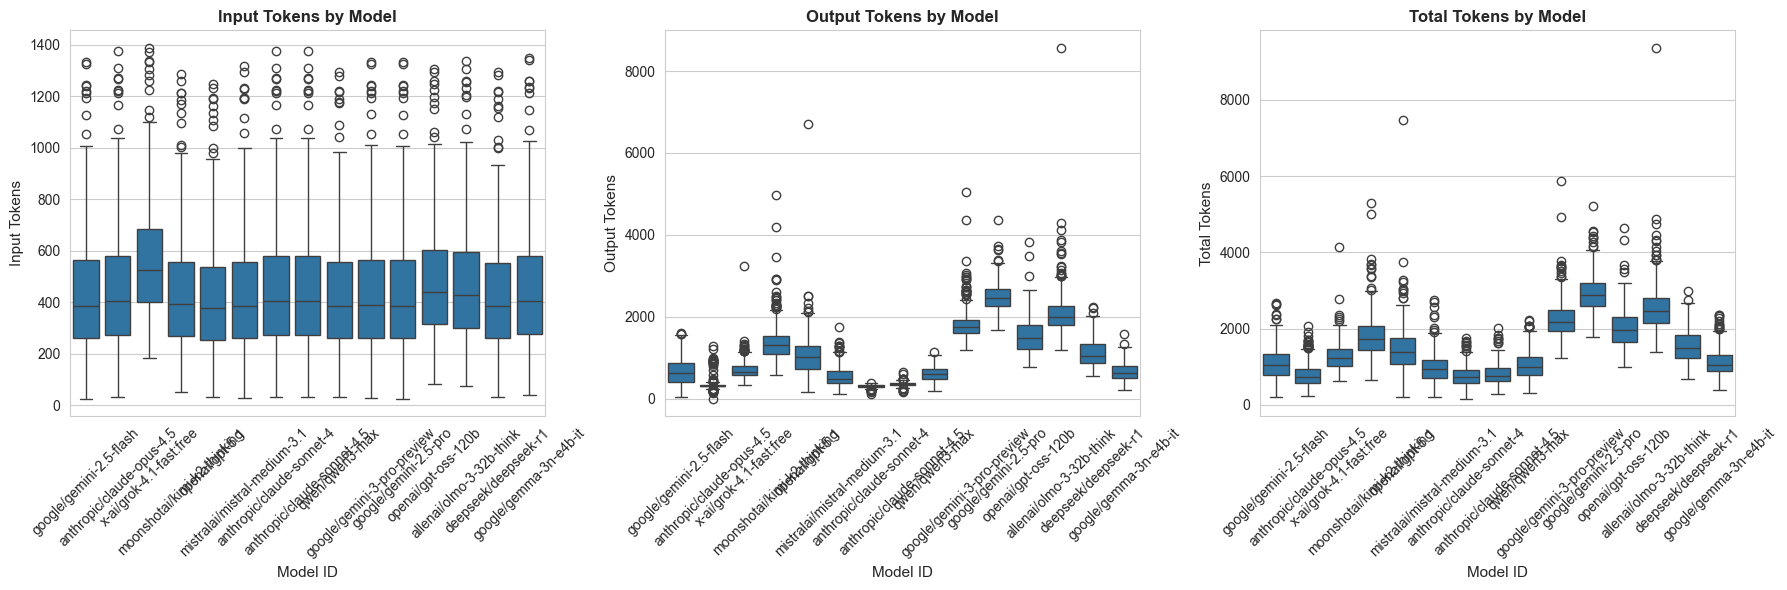

In [1284]:
# Token usage comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_success, x='model_id', y='input_tokens', ax=axes[0])
axes[0].set_title("Input Tokens by Model", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Model ID", fontsize=11)
axes[0].set_ylabel("Input Tokens", fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_success, x='model_id', y='output_tokens', ax=axes[1])
axes[1].set_title("Output Tokens by Model", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Model ID", fontsize=11)
axes[1].set_ylabel("Output Tokens", fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_success, x='model_id', y='total_tokens', ax=axes[2])
axes[2].set_title("Total Tokens by Model", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Model ID", fontsize=11)
axes[2].set_ylabel("Total Tokens", fontsize=11)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Response Quality


In [1285]:
# Response length analysis
df_success['response_length'] = df_success['response_text'].str.len()
df_success['word_count'] = df_success['response_text'].str.split().str.len()

# Short responses detection
short_responses = df_success[df_success['response_length'] < 50]

print("Response Length Statistics:")
print(f"  Mean length: {df_success['response_length'].mean():.0f} characters")
print(f"  Median length: {df_success['response_length'].median():.0f} characters")
print(f"  Min length: {df_success['response_length'].min():.0f} characters")
print(f"  Max length: {df_success['response_length'].max():.0f} characters")
print(f"\nWord Count Statistics:")
print(f"  Mean words: {df_success['word_count'].mean():.0f} words")
print(f"  Median words: {df_success['word_count'].median():.0f} words")
print(f"\nShort responses (< 50 chars): {len(short_responses)}")
if len(short_responses) > 0:
    print("\nShort response examples:")
    for idx, row in short_responses.head(5).iterrows():
        print(f"  {row['prompt_identifier']} / {row['model_id']}: {row['response_length']} chars")


Response Length Statistics:
  Mean length: 2682 characters
  Median length: 2258 characters
  Min length: 201 characters
  Max length: 12754 characters

Word Count Statistics:
  Mean words: 437 words
  Median words: 370 words

Short responses (< 50 chars): 0


In [1286]:
# Error analysis
# Convert to string for safe string operations (handles NaN)
error_str = df['error'].astype(str)
df_with_errors = df[
    df['error'].notna() & 
    (error_str != 'nan') & 
    (error_str.str.strip() != '')
].copy()

if len(df_with_errors) > 0:
    error_stats = df_with_errors.groupby('model_id').agg({
        'error': 'count',
        'retry_count': ['mean', 'max'],
    }).round(2)
    
    error_stats.columns = ['error_count', 'avg_retries', 'max_retries']
    
    print("Error Statistics by Model:")
    print(error_stats.sort_values('error_count', ascending=False).to_string())
    
    print(f"\nTotal failed responses: {len(df_with_errors)}")
    print(f"Total retries: {df_with_errors['retry_count'].sum()}")
else:
    print("✓ No errors found in the dataset")


✓ No errors found in the dataset


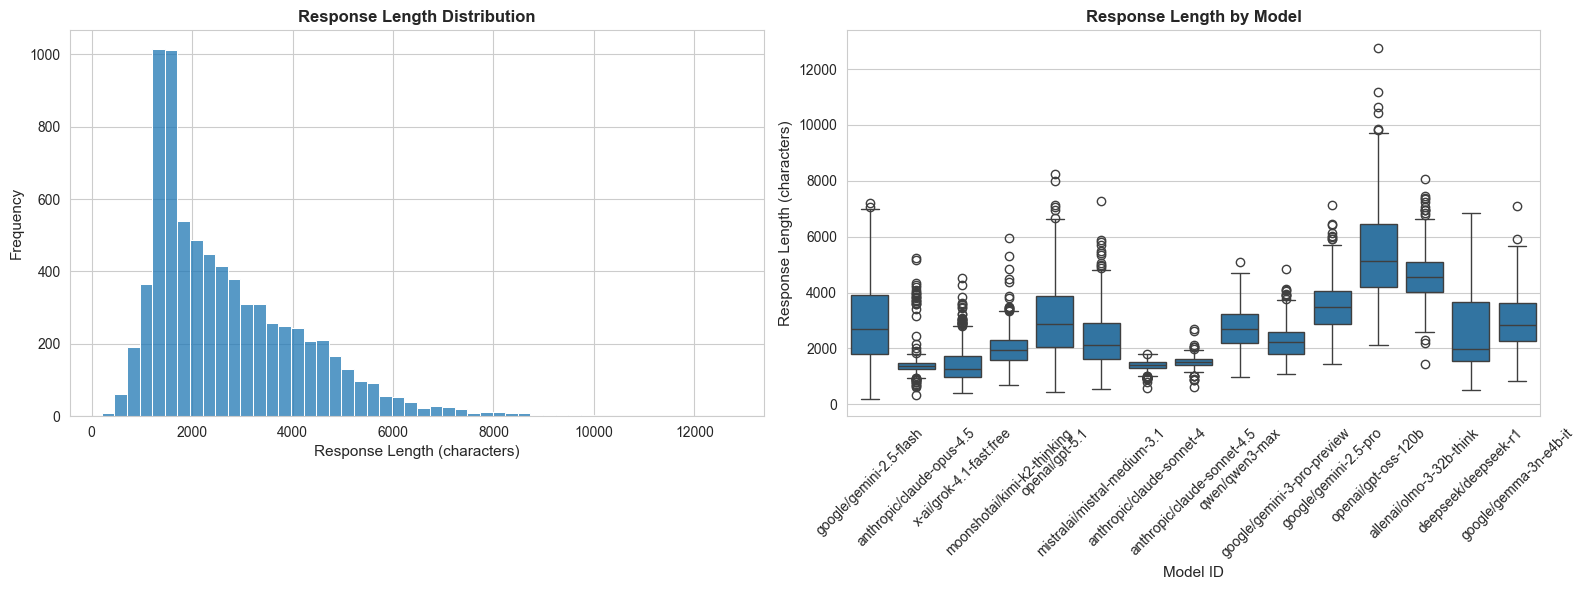

In [1287]:
# Response length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(
    data=df_success,
    x='response_length',
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Response Length Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Response Length (characters)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)

# Box plot by model
sns.boxplot(
    data=df_success,
    x='model_id',
    y='response_length',
    ax=axes[1]
)
axes[1].set_title("Response Length by Model", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Model ID", fontsize=11)
axes[1].set_ylabel("Response Length (characters)", fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Time-based Analysis


In [1288]:
# Parse timestamps
df_success['timestamp_parsed'] = pd.to_datetime(df_success['timestamp'])

# Responses over time
df_time = df_success.groupby([pd.Grouper(key='timestamp_parsed', freq='H'), 'model_id']).size().reset_index()
df_time.columns = ['timestamp', 'model_id', 'count']

# Processing rate
time_span = (df_success['timestamp_parsed'].max() - df_success['timestamp_parsed'].min()).total_seconds() / 3600
total_responses = len(df_success)
responses_per_hour = total_responses / time_span if time_span > 0 else 0

print("Time-based Statistics:")
print(f"  First response: {df_success['timestamp_parsed'].min()}")
print(f"  Last response: {df_success['timestamp_parsed'].max()}")
print(f"  Time span: {time_span:.2f} hours")
print(f"  Total responses: {total_responses}")
print(f"  Processing rate: {responses_per_hour:.1f} responses/hour")


Time-based Statistics:
  First response: 2025-11-30 19:16:07+00:00
  Last response: 2025-12-01 20:48:05+00:00
  Time span: 25.53 hours
  Total responses: 7500
  Processing rate: 293.7 responses/hour


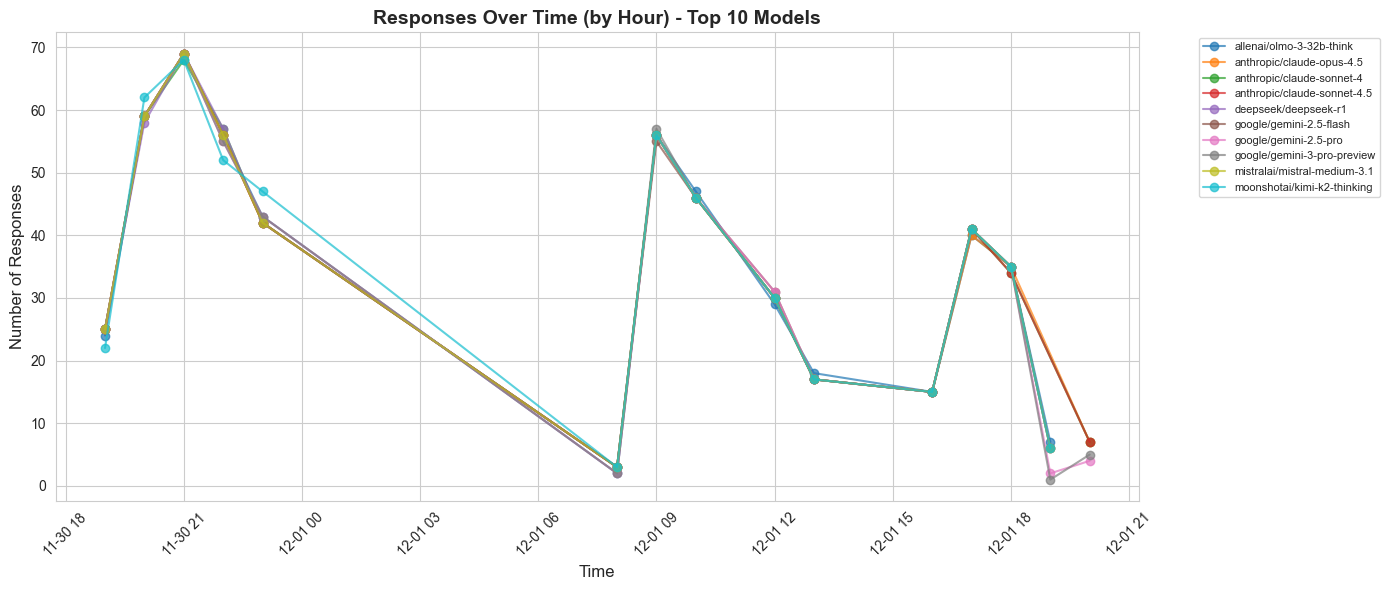

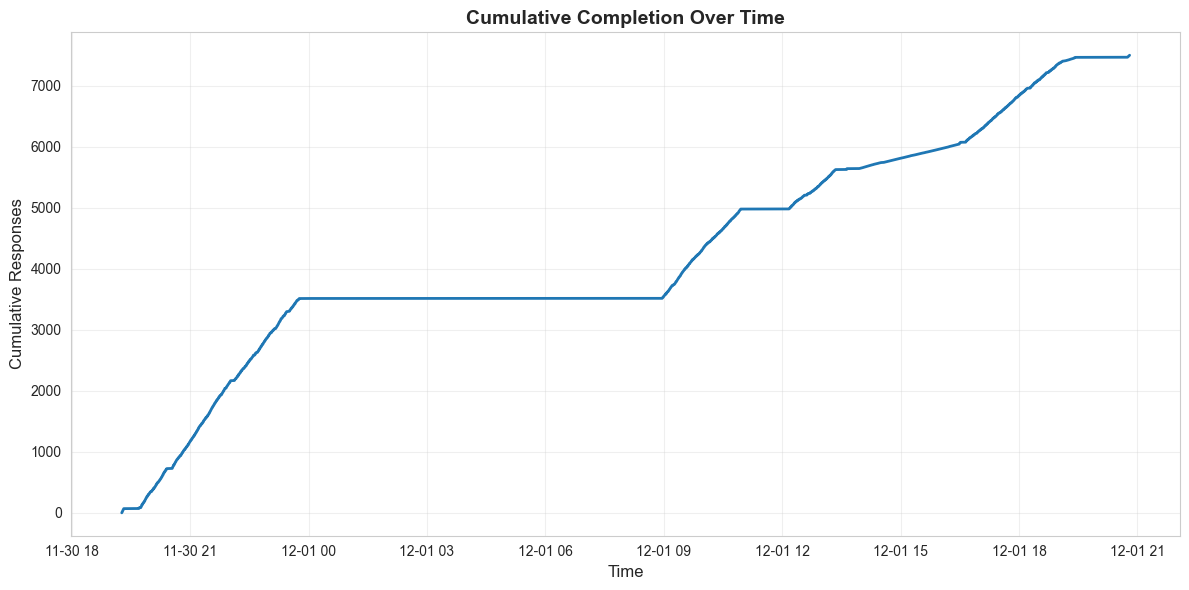

In [1289]:
# Timeline visualization
if len(df_time) > 0:
    # Static matplotlib version
    plt.figure(figsize=(14, 6))
    for model in df_time['model_id'].unique()[:10]:  # Limit to first 10 models for readability
        model_data = df_time[df_time['model_id'] == model]
        plt.plot(model_data['timestamp'], model_data['count'], marker='o', label=model, alpha=0.7)
    plt.title("Responses Over Time (by Hour) - Top 10 Models", fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Number of Responses", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Interactive plotly version (if available)
    try:
        fig = px.line(
            df_time,
            x='timestamp',
            y='count',
            color='model_id',
            title="Responses Over Time (Interactive)",
            labels={'count': 'Number of Responses', 'timestamp': 'Time'}
        )
        fig.update_layout(height=500)
        fig.show()
    except Exception:
        pass
    
    # Cumulative completion
    cumulative = df_success.groupby('timestamp_parsed').size().cumsum()
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative.index, cumulative.values, linewidth=2)
    plt.title("Cumulative Completion Over Time", fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Cumulative Responses", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No time data available for visualization.")


## Summary


In [1290]:
# Generate summary report
print("=" * 80)
print("PAID BENCHMARK RUN SUMMARY")
print("=" * 80)
print(f"\nRun Hash: {RUN_HASH}")
print(f"Run Directory: {run_dir_rel}")
if cost_data['started_at']:
    print(f"Started: {cost_data['started_at']}")
if cost_data['last_updated']:
    print(f"Last Updated: {cost_data['last_updated']}")

print(f"\nOverall Statistics:")
print(f"  Total records: {len(df)}")
print(f"  Successful responses: {len(df_success)}")
print(f"  Failed responses: {len(df) - len(df_success)}")
print(f"  Unique prompts: {df['prompt_identifier'].nunique()}")
print(f"  Unique models: {df['model_id'].nunique()}")
print(f"  Total cost: ${total_cost:.4f}")

print(f"\nCompletion Statistics:")
print(f"  Fully completed prompts: {fully_completed_prompts}/{total_prompts}")
print(f"  Incomplete prompts: {incomplete_prompts}")
print(f"  Overall completion rate: {overall_completion:.1f}%")

print(f"\nPerformance Statistics:")
print(f"  Average latency: {df_success['latency_ms'].mean():.0f} ms")
print(f"  Average tokens per response: {df_success['total_tokens'].mean():.0f}")
print(f"  Average response length: {df_success['response_length'].mean():.0f} characters")

print(f"\nQuality Checks:")
print(f"  Empty responses: {validation['empty_responses']}")
print(f"  Errors: {validation['error_count']}")
print(f"  Short responses (< 50 chars): {len(short_responses)}")

if incomplete_prompts > 0:
    print(f"\n⚠️  WARNING: {incomplete_prompts} prompts are incomplete (missing models)")
if validation['empty_responses'] > 0:
    print(f"⚠️  WARNING: {validation['empty_responses']} responses are empty")
if validation['error_count'] > 0:
    print(f"⚠️  WARNING: {validation['error_count']} responses have errors")


PAID BENCHMARK RUN SUMMARY

Run Hash: 95b19ea16ead8ca5
Run Directory: run_95b19ea16ead8ca5
Started: 2025-11-30T19:16:02Z
Last Updated: 2025-12-01T20:48:06Z

Overall Statistics:
  Total records: 7500
  Successful responses: 7500
  Failed responses: 0
  Unique prompts: 500
  Unique models: 15
  Total cost: $49.0645

Completion Statistics:
  Fully completed prompts: 500/500
  Incomplete prompts: 0
  Overall completion rate: 100.0%

Performance Statistics:
  Average latency: 20713 ms
  Average tokens per response: 1484
  Average response length: 2682 characters

Quality Checks:
  Empty responses: 0
  Errors: 0
  Short responses (< 50 chars): 0


In [1291]:
# Export analysis results
export_dir = run_dir / 'analysis'
export_dir.mkdir(exist_ok=True)

# Export model summary
model_summary = df_success.groupby('model_id').agg({
    'prompt_identifier': 'nunique',
    'latency_ms': ['mean', 'median'],
    'total_tokens': ['mean', 'sum'],
    'cost_usd': ['sum', 'mean'],
    'response_length': 'mean'
}).round(2)

model_summary.columns = [
    'Prompts_Answered',
    'Avg_Latency_ms',
    'Median_Latency_ms',
    'Avg_Tokens',
    'Total_Tokens',
    'Total_Cost_USD',
    'Avg_Cost_USD',
    'Avg_Response_Length'
]

model_summary['Completion_Rate_%'] = (model_summary['Prompts_Answered'] / total_prompts * 100).round(1)

# Export prompt summary
prompt_summary = df_success.groupby('prompt_identifier').agg({
    'model_id': 'nunique',
    'response_length': 'mean',
    'latency_ms': 'mean',
    'total_tokens': 'mean',
    'cost_usd': 'sum'
}).round(2)

prompt_summary.columns = [
    'Models_Answered',
    'Avg_Response_Length',
    'Avg_Latency_ms',
    'Avg_Tokens',
    'Total_Cost_USD'
]

prompt_summary['Completion_Rate_%'] = (prompt_summary['Models_Answered'] / total_models * 100).round(1)

# Save to CSV
model_summary.to_csv(export_dir / 'model_summary.csv')
prompt_summary.to_csv(export_dir / 'prompt_summary.csv')

print(f"✓ Exported summaries to:")
print(f"  - {export_dir / 'model_summary.csv'}")
print(f"  - {export_dir / 'prompt_summary.csv'}")


✓ Exported summaries to:
  - run_95b19ea16ead8ca5/analysis/model_summary.csv
  - run_95b19ea16ead8ca5/analysis/prompt_summary.csv
